In [ ]:
install.packages(c("ggplot2", "dplyr", "tidyr", "corrplot", "readr", "lubridate"))
library(ggplot2)
library(dplyr)
library(tidyr)
library(corrplot)
library(readr)
library(lubridate)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


corrplot 0.95 loaded


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




In [ ]:
customers  <- read_csv("customers.csv")
orders     <- read_csv("orders.csv")
deliveries <- read_csv("deliveries.csv")
drivers    <- read_csv("drivers.csv")
vehicles   <- read_csv("vehicles.csv")
hubs       <- read_csv("hubs.csv")
incidents  <- read_csv("incidents.csv")
complaints <- read_csv("complaints.csv")


clean_zone <- function(z) toupper(trimws(z))
customers$home_zone    <- clean_zone(customers$home_zone)
orders$pickup_zone     <- clean_zone(orders$pickup_zone)
drivers$base_zone      <- clean_zone(drivers$base_zone)
vehicles$assigned_zone <- clean_zone(vehicles$assigned_zone)
hubs$zone              <- clean_zone(hubs$zone)

cat("Data loaded\n")

Rows: 650 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): customer_id, home_zone, customer_type, preferred_channel, account_...
dbl  (3): age, loyalty_score, app_engagement_score
dttm (1): signup_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1250 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): order_id, customer_id, service_type, pickup_zone, dropoff_zone, pr...
dbl  (3): promised_window_hours, order_value, special_handling_flag
dttm (1): order_created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 950 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6)

Data loaded


In [ ]:
 master <- deliveries %>%
  left_join(orders,   by = "order_id") %>%
  left_join(drivers,  by = "driver_id") %>%
  left_join(vehicles, by = "vehicle_id") %>%
  left_join(hubs,     by = "hub_id")

cat("Master dataset rows:", nrow(master), "\n")
head(master)

Master dataset rows: 950 


delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,⋯,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version,hub_name,zone,hub_type,capacity_score
<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,⋯,<chr>,<dttm>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59,Failed,17.26,1,⋯,CENTRAL,2024-06-09 16:18:00,78.4,29849,Active,v2.2,Central Core,CENTRAL,Control,88
DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00,OnTime,10.34,1,⋯,AIRPORT,2025-09-17 08:52:00,68.6,78468,Active,v2.2,South Link,SOUTH,Dispatch,78
DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32,OnTime,7.92,0,⋯,EAST,2025-12-09 16:47:00,55.9,15278,Active,v2.2,South Link,SOUTH,Dispatch,78
DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08,Delayed,16.42,0,⋯,EAST,2025-06-05 13:40:00,83.3,85635,Active,v2.1,South Link,SOUTH,Dispatch,78
DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34,OnTime,14.52,1,⋯,RIVERSIDE,2025-05-24 09:58:00,94.2,210683,InRepair,v2.0,North Exchange,NORTH,Dispatch,82
DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52,Delayed,13.84,0,⋯,WEST,2025-12-29 15:01:00,69.7,73011,Active,v2.1,East Dock,EAST,Warehouse,74


# A tibble: 3 × 3
  delivery_status     n   pct
  <chr>           <int> <dbl>
1 Delayed           202  21.3
2 Failed            132  13.9
3 OnTime            616  64.8


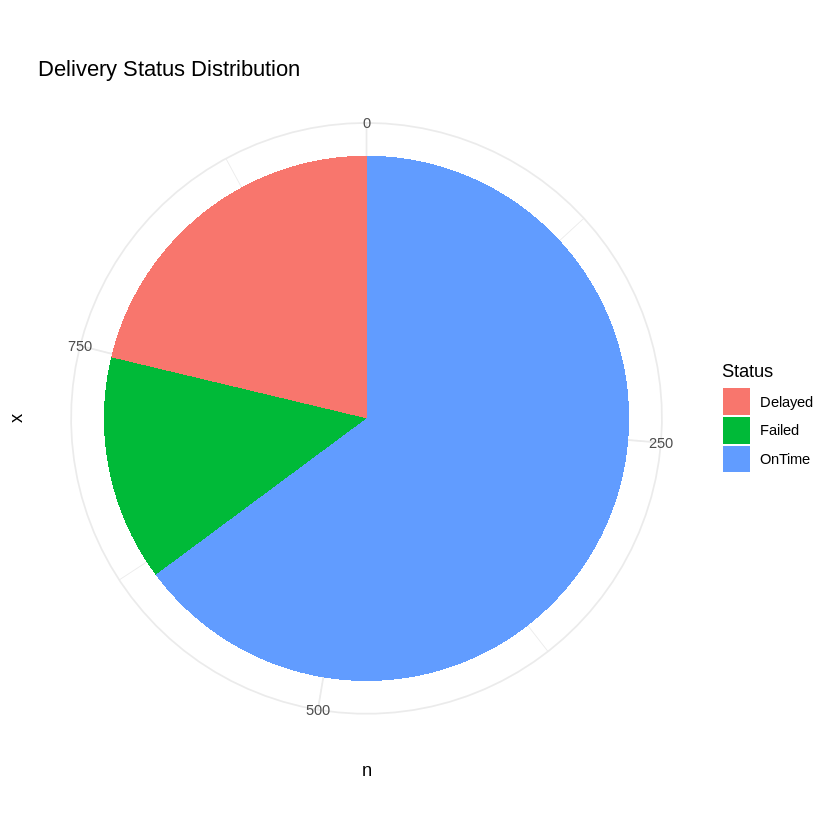

In [ ]:
status_counts <- deliveries %>%
  count(delivery_status) %>%
  mutate(pct = round(100 * n / sum(n), 1))

print(status_counts)

ggplot(status_counts, aes(x = "", y = n, fill = delivery_status)) +
  geom_col() +
  coord_polar("y") +
  labs(title = "Delivery Status Distribution", fill = "Status") +
  theme_minimal()

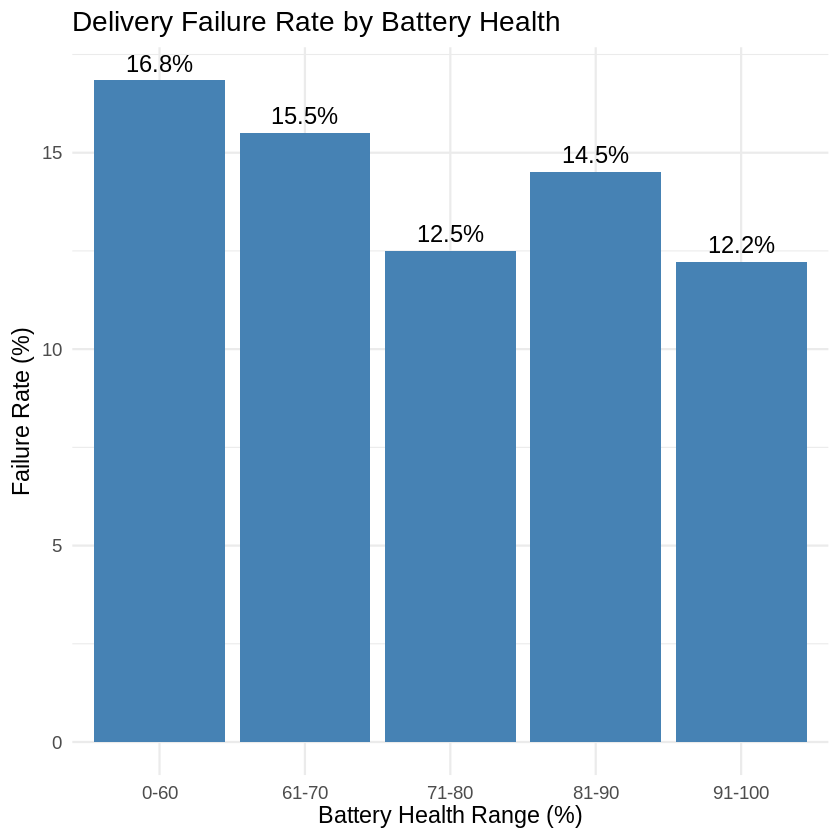

In [ ]:
library(dplyr)
library(ggplot2)

master_clean <- master %>%
  filter(!is.na(battery_health_pct)) %>%
  mutate(
    failed = ifelse(delivery_status == "Failed", 1, 0),

    battery_group = cut(
      battery_health_pct,
      breaks = c(0, 60, 70, 80, 90, 100),
      labels = c("0-60", "61-70", "71-80", "81-90", "91-100")
    )
  )


failure_rate <- master_clean %>%
  group_by(battery_group) %>%
  summarise(
    failure_percent = mean(failed) * 100
  )


ggplot(failure_rate, aes(x = battery_group, y = failure_percent)) +
  geom_col(fill = "steelblue") +
  geom_text(
    aes(label = paste0(round(failure_percent, 1), "%")),
    vjust = -0.5,
    size = 5
  ) +
  labs(
    title = "Delivery Failure Rate by Battery Health",
    x = "Battery Health Range (%)",
    y = "Failure Rate (%)"
  ) +
  theme_minimal(base_size = 14)

`geom_smooth()` using formula = 'y ~ x'



	Pearson's product-moment correlation

data:  driver_perf$driver_rating and driver_perf$avg_cust_rating
t = 3.0002, df = 168, p-value = 0.003109
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.07763177 0.36368097
sample estimates:
     cor 
0.225511 


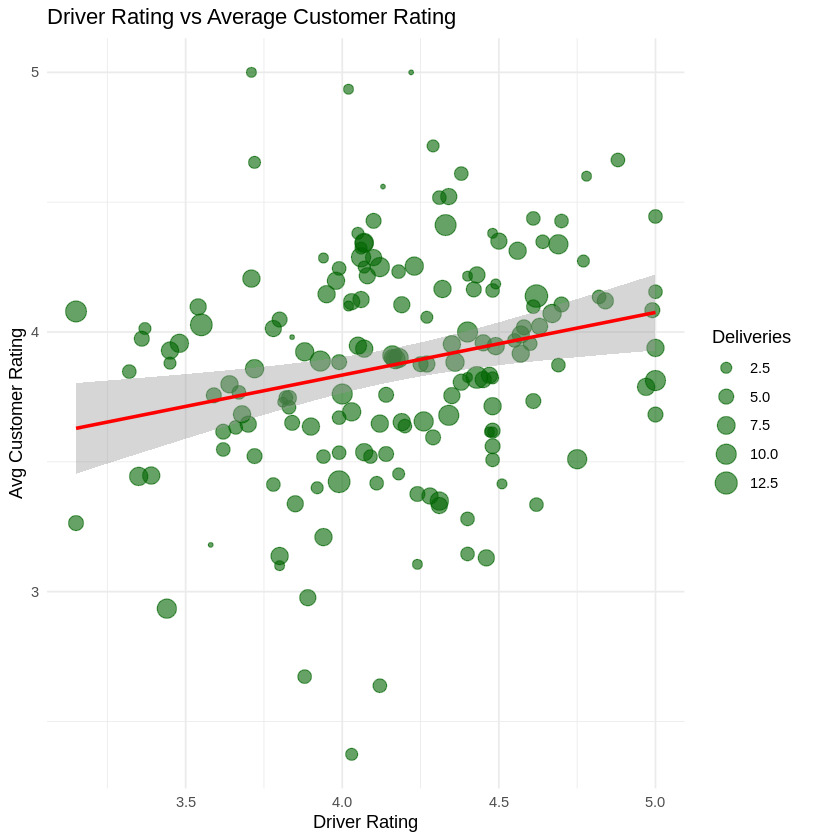

In [ ]:
driver_perf <- master %>%
  filter(!is.na(driver_rating), !is.na(customer_rating_post_delivery)) %>%
  group_by(driver_id, driver_rating, training_score) %>%
  summarise(
    avg_cust_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    total_deliveries = n(),
    .groups = "drop"
  )

ggplot(driver_perf, aes(x = driver_rating, y = avg_cust_rating)) +
  geom_point(aes(size = total_deliveries), alpha = 0.6, color = "darkgreen") +
  geom_smooth(method = "lm", color = "red") +
  labs(
    title = "Driver Rating vs Average Customer Rating",
    x = "Driver Rating",
    y = "Avg Customer Rating",
    size = "Deliveries"
  ) +
  theme_minimal()

# Correlation test
cor.test(driver_perf$driver_rating, driver_perf$avg_cust_rating)

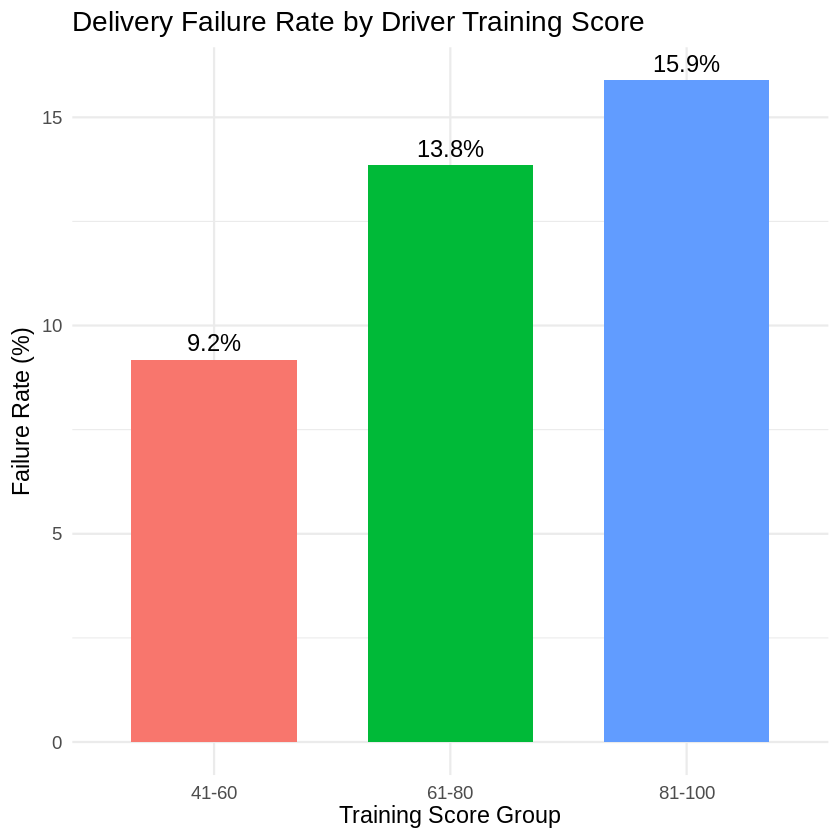

In [ ]:
library(dplyr)
library(ggplot2)

driver_failures <- master %>%
  filter(!is.na(training_score)) %>%

  mutate(
    training_group = cut(
      training_score,
      breaks = c(0, 20, 40, 60, 80, 100),
      labels = c("0-20", "21-40", "41-60", "61-80", "81-100")
    ),

    failed = ifelse(delivery_status == "Failed", 1, 0)
  ) %>%

  group_by(training_group) %>%
  summarise(
    failure_rate = mean(failed, na.rm = TRUE) * 100,
    total_deliveries = n(),
    .groups = "drop"
  )

ggplot(driver_failures,
       aes(x = training_group,
           y = failure_rate,
           fill = training_group)) +

  geom_col(width = 0.7) +

  geom_text(
    aes(label = paste0(round(failure_rate, 1), "%")),
    vjust = -0.5,
    size = 5
  ) +

  labs(
    title = "Delivery Failure Rate by Driver Training Score",
    x = "Training Score Group",
    y = "Failure Rate (%)"
  ) +

  theme_minimal(base_size = 14) +

  theme(legend.position = "none")

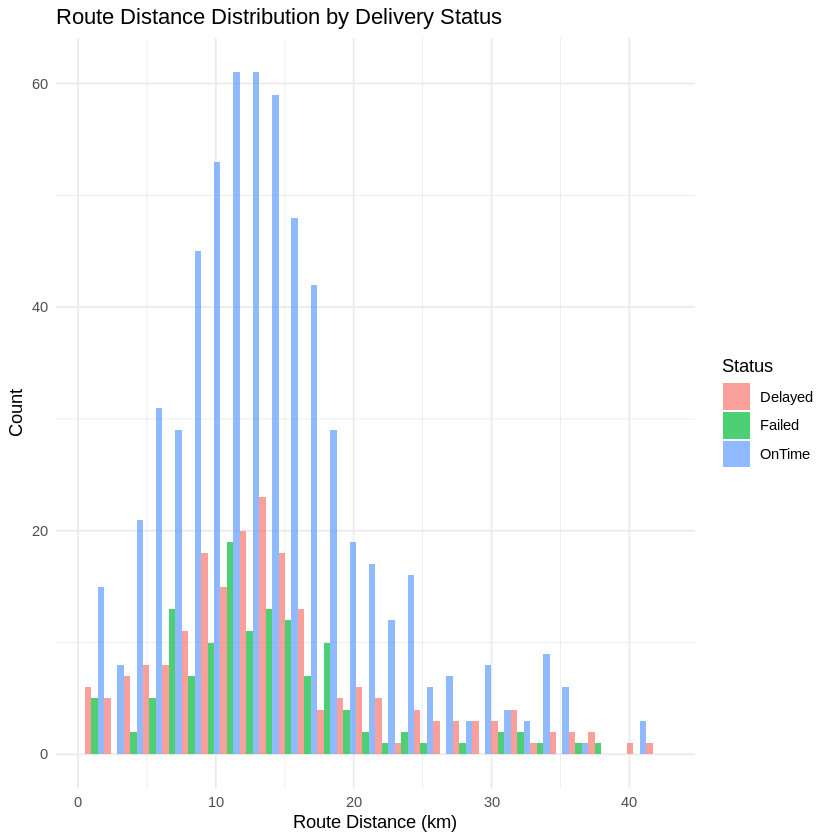

In [ ]:
ggplot(master, aes(x = route_distance_km, fill = delivery_status)) +
  geom_histogram(bins = 30, position = "dodge", alpha = 0.7) +
  labs(
    title = "Route Distance Distribution by Delivery Status",
    x = "Route Distance (km)",
    y = "Count",
    fill = "Status"
  ) +
  theme_minimal()

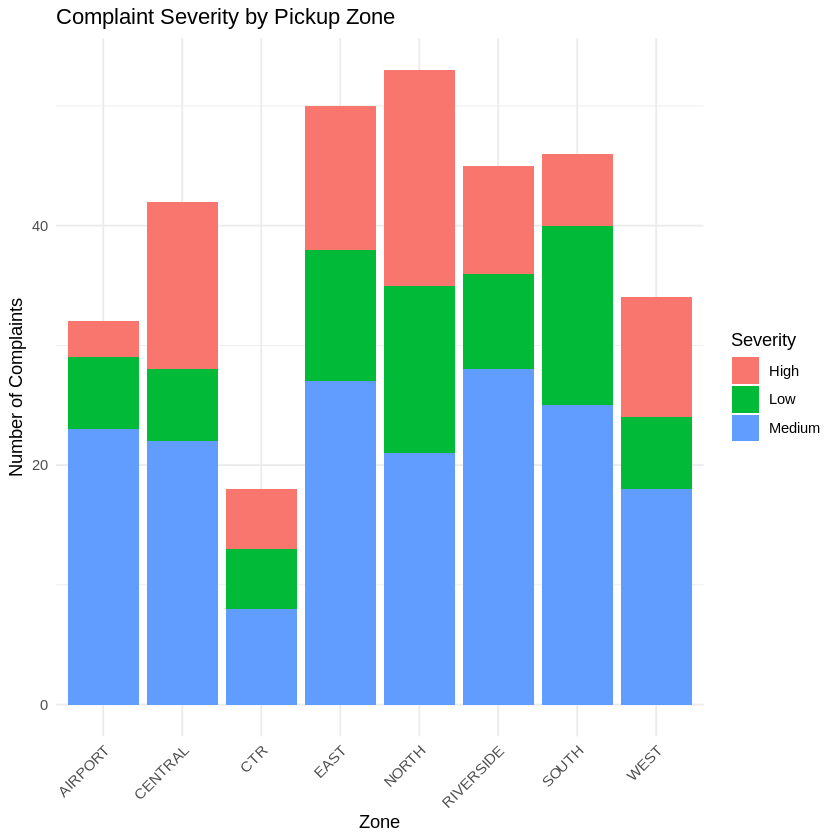

In [ ]:
complaints_zone <- complaints %>%
  left_join(orders, by = "order_id") %>%
  mutate(pickup_zone = clean_zone(pickup_zone)) %>%
  filter(!is.na(pickup_zone)) %>%
  count(pickup_zone, severity)

ggplot(complaints_zone, aes(x = pickup_zone, y = n, fill = severity)) +
  geom_bar(stat = "identity", position = "stack") +
  labs(
    title = "Complaint Severity by Pickup Zone",
    x = "Zone",
    y = "Number of Complaints",
    fill = "Severity"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

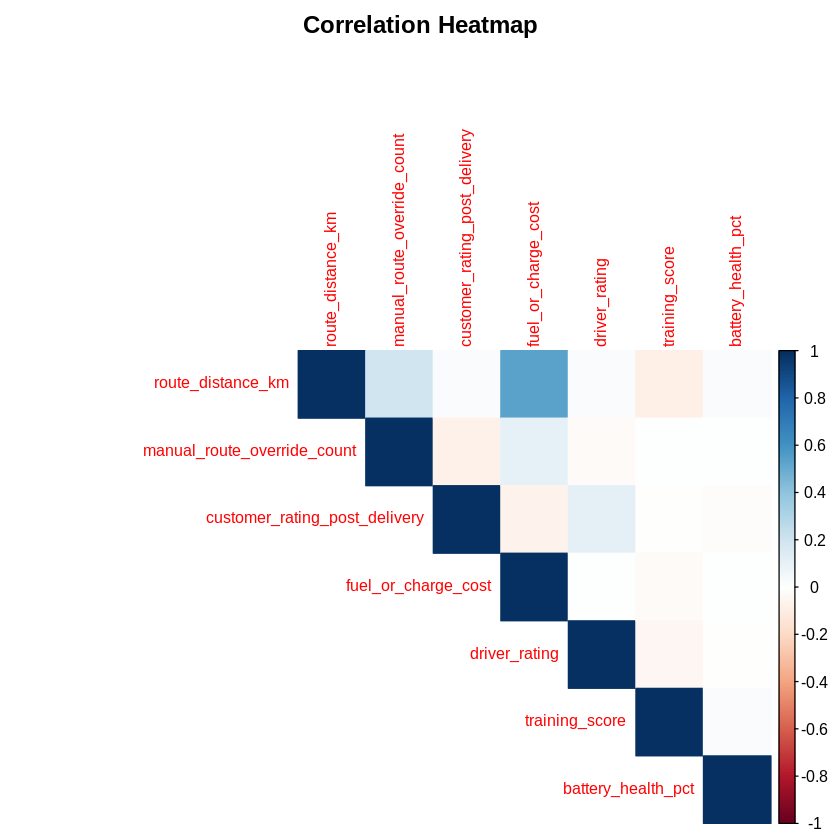

In [ ]:
num_vars <- master %>%
  select(route_distance_km, manual_route_override_count,
         customer_rating_post_delivery, fuel_or_charge_cost,
         driver_rating, training_score, battery_health_pct) %>%
  drop_na()

cor_matrix <- cor(num_vars)
corrplot(cor_matrix, method = "color", type = "upper",
         tl.cex = 0.8, title = "Correlation Heatmap", mar = c(0,0,2,0))

# A tibble: 102 × 4
   incident_type    severity resolution_status     n
   <chr>            <chr>    <chr>             <int>
 1 CustomerNoShow   Medium   Closed               10
 2 ProofMissing     Low      Closed               10
 3 RouteDeviation   Low      Closed               10
 4 AppSyncError     Medium   PendingVendor         8
 5 BatteryAlert     Medium   Closed                7
 6 TemperatureIssue Medium   Closed                7
 7 BatteryAlert     Medium   Open                  6
 8 CustomerNoShow   Low      Open                  6
 9 ProofMissing     Medium   Closed                6
10 RouteDeviation   High     Open                  6
# ℹ 92 more rows


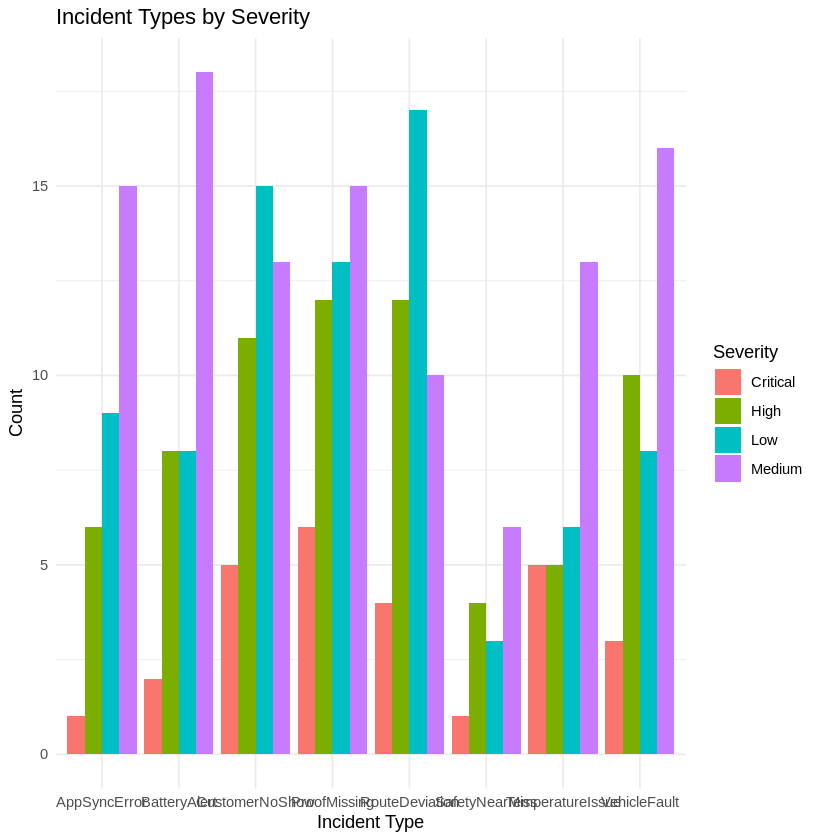

In [ ]:
inc_summary <- incidents %>%
  count(incident_type, severity, resolution_status) %>%
  arrange(desc(n))

print(inc_summary)

ggplot(incidents, aes(x = incident_type, fill = severity)) +
  geom_bar(position = "dodge") +
  labs(
    title = "Incident Types by Severity",
    x = "Incident Type",
    y = "Count",
    fill = "Severity"
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: label.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


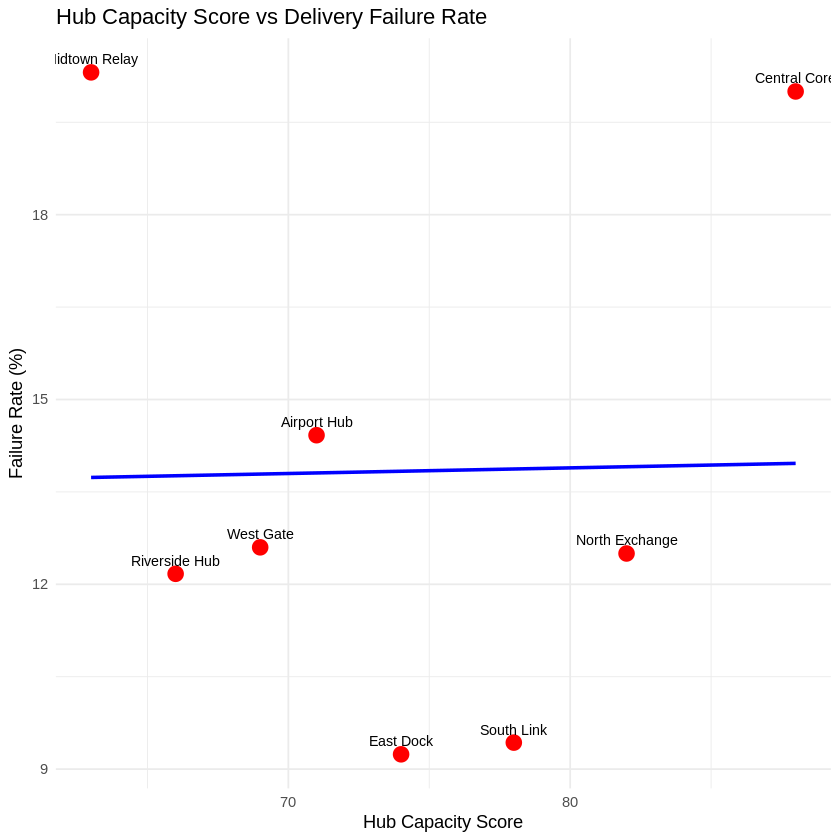

In [ ]:
hub_analysis <- master %>%
  group_by(hub_id, hub_name, zone, capacity_score) %>%
  summarise(
    total = n(),
    failures = sum(delivery_status == "Failed", na.rm = TRUE),
    failure_rate = round(100 * failures / total, 2),
    .groups = "drop"
  )

ggplot(hub_analysis, aes(x = capacity_score, y = failure_rate, label = hub_name)) +
  geom_point(size = 4, color = "red") +
  geom_text(vjust = -0.8, size = 3) +
  geom_smooth(method = "lm", se = FALSE, color = "blue") +
  labs(
    title = "Hub Capacity Score vs Delivery Failure Rate",
    x = "Hub Capacity Score",
    y = "Failure Rate (%)"
  ) +
  theme_minimal()

In [ ]:
cat("=== KEY ANALYTICAL FINDINGS ===\n\n")

cat("1. Overall failure rate: ",
    round(100 * mean(deliveries$delivery_status == "Failed"), 1), "%\n")

cat("2. Avg resolution days for complaints: ",
    round(mean(complaints$resolution_days, na.rm = TRUE), 1), "\n")

cat("3. Total compensation paid: £",
    round(sum(complaints$compensation_amount, na.rm = TRUE), 2), "\n")

cat("4. Vehicles in repair: ",
    sum(vehicles$maintenance_status == "InRepair", na.rm = TRUE), "\n")

cat("5. Drivers with rating below 3.5: ",
    sum(drivers$driver_rating < 3.5, na.rm = TRUE), "\n")

=== KEY ANALYTICAL FINDINGS ===

1. Overall failure rate:  13.9 %
2. Avg resolution days for complaints:  7.9 
3. Total compensation paid: £ 6158.19 
4. Vehicles in repair:  36 
5. Drivers with rating below 3.5:  11 
